# Method Comparison: Industrial/Experimental Data (VarA/VarB)

**Objective:** Compare all four delay detection methods on industrial sensor data:
1. **Kuramoto** (phase synchronization via Hilbert transform)
2. **JRP** (Joint Recurrence Plots - state-space synchronization)
3. **Cross-Correlation** (linear similarity)
4. **Mutual Information** (nonlinear dependency)

Data: VarA and VarB from `datos_ind.pqt` (industrial sensor data)
Real lag: computed from physical transit time (distance/velocity)

In [1]:
# --- IMPORTS ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import correlate, correlation_lags, hilbert
from scipy.spatial.distance import pdist, squareform
from scipy.ndimage import uniform_filter1d
from sklearn.feature_selection import mutual_info_regression

from synch_analysis import (
    ParquetDataSource,
    DelayCharacterizationPipeline,
)

In [2]:
# Publication-quality figure settings
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 12,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans', 'Liberation Sans'],
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.grid': False,
    'axes.axisbelow': True,
    'axes.spines.top': True,
    'axes.spines.right': True,
    'axes.linewidth': 0.8,
    'xtick.major.size': 4,
    'xtick.major.width': 0.8,
    'ytick.major.size': 4,
    'ytick.major.width': 0.8,
    'legend.frameon': True,
    'legend.framealpha': 0.9,
    'legend.edgecolor': 'black',
    'lines.linewidth': 1.0,
    'lines.markersize': 4
})

## Configuration

Set the Parquet file path, column names, and time window for analysis.

In [3]:
# --- DATA SOURCE SETUP (VarA/VarB) ---
parquet = ParquetDataSource(
    file_path="../data/datos_ind.pqt",
    column_a="VarA",
    column_b="VarB",
    index_start="2021-11-03 12:10:00",
    index_end="2021-11-03 12:30:00",    
    window=1,             # Rolling mean window
    lag=None,              # No initial lag
    sampling_rate=1.0,     # 1 Hz
)

signal_pair = parquet.load()
s1 = signal_pair.signal_b
s2 = signal_pair.signal_a
sr = signal_pair.sampling_rate

print(f'Signal A: {signal_pair.name_a} ({len(s2)} samples)')
print(f'Signal B: {signal_pair.name_b} ({len(s1)} samples)')
print(f'Sampling rate: {sr} Hz')

Signal A: VarA (1199 samples)
Signal B: VarB (1199 samples)
Sampling rate: 1.0 Hz


## Real Lag Calculation (Physical Transit Time)

In [4]:
# --- REAL LAG CALCULATION ---
df = pd.read_parquet('../data/datos_ind.pqt')
df['fecha'] = pd.to_datetime(df['fecha'])
df = df.set_index('fecha')

# Use same time window as analysis
start_time = "2021-11-03 12:10:00"
end_time = "2021-11-03 12:30:00"

df_hour = df.loc[start_time:end_time].copy()

vel = df_hour['Velocidad'].mean()

# Physical transit distance (belt/conveyor)
distance = 18600  # units
real_lag = int(distance / vel)
real_lag_sec = real_lag / sr

print(f'Average velocity: {vel:.2f} units/s')
print(f'Real lag (|distance/speed|): {real_lag}s ({real_lag/60:.1f} min)')

Average velocity: 205.00 units/s
Real lag (|distance/speed|): 90s (1.5 min)


## 1. Run DelayCharacterizationPipeline (Kuramoto + JRP)

In [5]:
# --- KURAMOTO + JRP PIPELINE ---
pipeline_kjrp = DelayCharacterizationPipeline(
    parquet,
    max_lag=500,        # Search up to x seconds
    lag_step=5,        # second steps
    jrp_m=3,            # Embedding dimension
    jrp_tau=1,          # Embedding delay
    jrp_rate=0.3,      # Recurrence rate
    jrp_smooth_size=10,  # Smoothing window
)
pipeline_kjrp.run()

results_kjrp = pipeline_kjrp.get_results()
opt_kjrp = pipeline_kjrp.get_optimal_lags()

print(f'Kuramoto best lag: {opt_kjrp["best_kuramoto_lag"]} steps ({opt_kjrp["best_kuramoto_lag"]/sr:.1f}s)')
print(f'JRP best lag: {opt_kjrp["best_jrp_lag"]} steps ({opt_kjrp["best_jrp_lag"]/sr:.1f}s)')
print(f'Combined best lag: {opt_kjrp["best_combined_lag"]} steps ({opt_kjrp["best_combined_lag"]/sr:.1f}s)')

Loading data: Parquet: ../data/datos_ind.pqt [VarA vs VarB]
  Signal A: VarA (1199 samples)
  Signal B: VarB (1199 samples)
Running Kuramoto lag sweep (lags: 201)...
Running JRP lag sweep...
Computing combined scores...
  Best Kuramoto lag: 90 steps (90.000 s)
  Best JRP lag: 90 steps (90.000 s)
  Best Combined lag: 90 steps (90.000 s)
Kuramoto best lag: 90 steps (90.0s)
JRP best lag: 90 steps (90.0s)
Combined best lag: 90 steps (90.0s)


## 2. Cross-Correlation Method

In [6]:
# --- CROSS-CORRELATION ---
s1_norm = (s1 - np.mean(s1)) / np.std(s1)
s2_norm = (s2 - np.mean(s2)) / np.std(s2)

max_lag = min(500, len(s1) // 4)
corr = correlate(s1_norm, s2_norm, mode='full')
lags_cc = correlation_lags(len(s1_norm), len(s2_norm), mode='full')

mask = (lags_cc >= -max_lag) & (lags_cc <= max_lag)
lags_cc = lags_cc[mask]
corr = corr[mask]

peak_idx = np.argmax(corr)
cc_lag = lags_cc[peak_idx]
cc_max = corr[peak_idx]
cc_lag_sec = cc_lag / sr

print(f'Cross-correlation peak: {cc_lag} steps ({cc_lag_sec:.1f}s)')
print(f'Max correlation: {cc_max:.4f}')

Cross-correlation peak: 91 steps (91.0s)
Max correlation: 638.7661


## 3. Mutual Information Method

In [7]:
# --- MUTUAL INFORMATION (sklearn) ---
def mutual_info_lag_sklearn(s1, s2, max_lag):
    mi_values = []
    mi_lags = np.arange(-max_lag, max_lag + 1)
    for lag in mi_lags:
        if lag > 0:
            s1_shifted = s1[lag:]; s2_shifted = s2[:-lag]
        elif lag < 0:
            s1_shifted = s1[:lag]; s2_shifted = s2[-lag:]
        else:
            s1_shifted = s1; s2_shifted = s2
        mi = mutual_info_regression(s1_shifted.reshape(-1, 1), s2_shifted, n_neighbors=5, random_state=0)
        mi_values.append(mi[0])
    return mi_lags, np.array(mi_values)

max_lag = min(500, len(s1) // 4)
mi_lags, mi_values = mutual_info_lag_sklearn(s1_norm, s2_norm, max_lag)
mi_peak_idx = np.argmax(mi_values)
mi_lag = mi_lags[mi_peak_idx]
mi_max = mi_values[mi_peak_idx]
mi_lag_sec = mi_lag / sr

print(f'Mutual Information peak: {mi_lag} steps ({mi_lag_sec:.1f}s)')
print(f'Max MI: {mi_max:.4f}')

Mutual Information peak: 159 steps (159.0s)
Max MI: 0.2362


## 4. Visual Comparison: All Methods

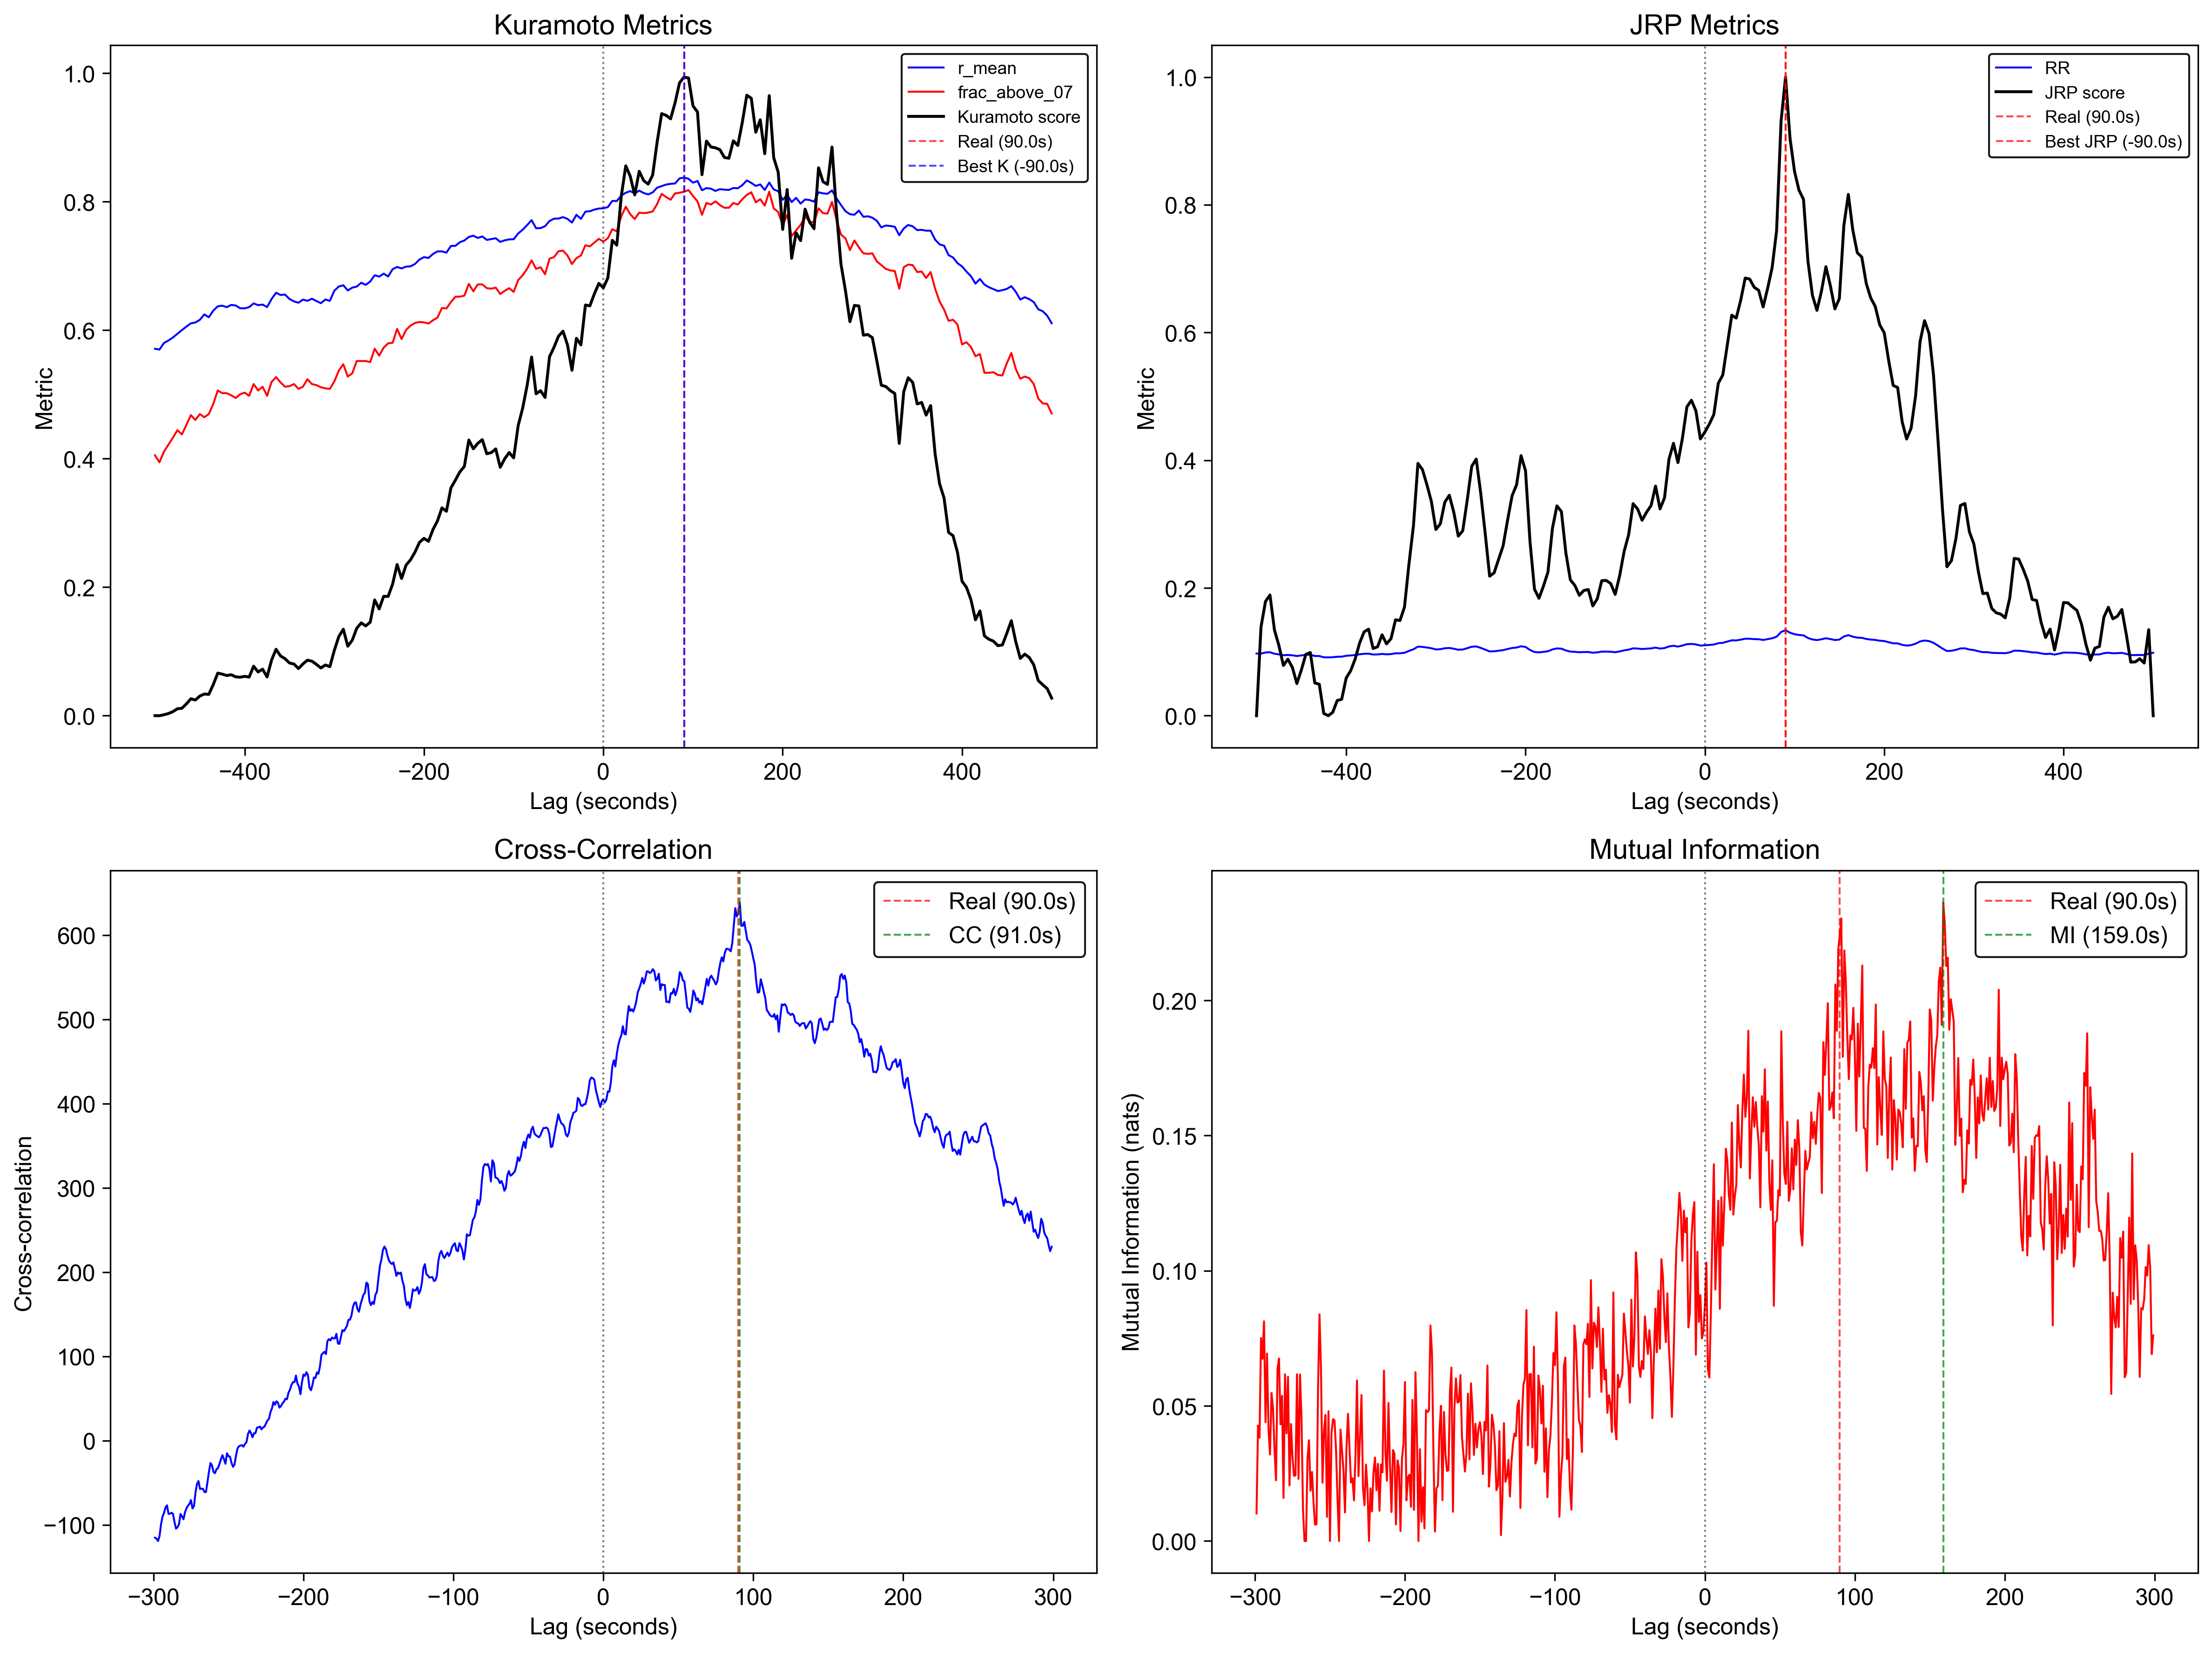

In [9]:
# --- PLOT ALL METHODS ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('white')

# 1. Kuramoto metrics
df_k = results_kjrp.copy()
df_k['lag_sec_pos'] = df_k['lag_tu']  # Invert lag for display
axes[0, 0].plot(df_k['lag_sec_pos'], df_k['r_mean'], 'b-', linewidth=1, label='r_mean')
axes[0, 0].plot(df_k['lag_sec_pos'], df_k['frac_above_07'], 'r-', linewidth=1, label='frac_above_07')
axes[0, 0].plot(df_k['lag_sec_pos'], df_k['kuramoto_score'], 'k-', linewidth=1.5, label='Kuramoto score')
axes[0, 0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0, 0].axvline(x=real_lag_sec, color='r', linestyle='--', alpha=0.7, label=f'Real ({real_lag_sec:.1f}s)')
axes[0, 0].axvline(x=opt_kjrp['best_kuramoto_lag']/sr, color='b', linestyle='--', alpha=0.7, label=f'Best K ({-opt_kjrp["best_kuramoto_lag"]/sr:.1f}s)')
axes[0, 0].set_xlabel('Lag (seconds)')
axes[0, 0].set_ylabel('Metric')
axes[0, 0].set_title('Kuramoto Metrics')
axes[0, 0].legend(frameon=True, framealpha=0.9, edgecolor='black', fontsize=9)

# 2. JRP metrics
jrp_df = df_k[df_k['jrp_RR'] > 0].copy()
axes[0, 1].plot(jrp_df['lag_sec_pos'], jrp_df['jrp_RR'], 'b-', linewidth=1, label='RR')
axes[0, 1].plot(jrp_df['lag_sec_pos'], jrp_df['jrp_score'], 'k-', linewidth=1.5, label='JRP score')
axes[0, 1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0, 1].axvline(x=real_lag_sec, color='r', linestyle='--', alpha=0.7, label=f'Real ({real_lag_sec:.1f}s)')
axes[0, 1].axvline(x=opt_kjrp['best_jrp_lag']/sr, color='r', linestyle='--', alpha=0.7, label=f'Best JRP ({-opt_kjrp["best_jrp_lag"]/sr:.1f}s)')
axes[0, 1].set_xlabel('Lag (seconds)')
axes[0, 1].set_ylabel('Metric')
axes[0, 1].set_title('JRP Metrics')
axes[0, 1].legend(frameon=True, framealpha=0.9, edgecolor='black', fontsize=9)

# 3. Cross-correlation
axes[1, 0].plot(lags_cc / sr, corr, 'b-', linewidth=1)
axes[1, 0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1, 0].axvline(x=real_lag_sec, color='r', linestyle='--', alpha=0.7, label=f'Real ({real_lag_sec:.1f}s)')
axes[1, 0].axvline(x=cc_lag_sec, color='g', linestyle='--', alpha=0.7, label=f'CC ({cc_lag_sec:.1f}s)')
axes[1, 0].set_xlabel('Lag (seconds)')
axes[1, 0].set_ylabel('Cross-correlation')
axes[1, 0].set_title('Cross-Correlation')
axes[1, 0].legend(frameon=True, framealpha=0.9, edgecolor='black')

# 4. Mutual Information
axes[1, 1].plot(mi_lags / sr, mi_values, 'r-', linewidth=1)
axes[1, 1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1, 1].axvline(x=real_lag_sec, color='r', linestyle='--', alpha=0.7, label=f'Real ({real_lag_sec:.1f}s)')
axes[1, 1].axvline(x=mi_lag_sec, color='g', linestyle='--', alpha=0.7, label=f'MI ({mi_lag_sec:.1f}s)')
axes[1, 1].set_xlabel('Lag (seconds)')
axes[1, 1].set_ylabel('Mutual Information (nats)')
axes[1, 1].set_title('Mutual Information')
axes[1, 1].legend(frameon=True, framealpha=0.9, edgecolor='black')

plt.tight_layout()
plt.show()

## 5. Summary Table

In [10]:
# --- SUMMARY TABLE ---
summary = pd.DataFrame({
    'Method': ['Real (Physical)', 'Kuramoto (score)', 'Kuramoto (r_mean)', 'JRP (score)', 'JRP (RR)', 'Cross-Correlation', 'Mutual Information'],
    'Lag (steps)': [real_lag,
                    opt_kjrp['best_kuramoto_lag'],
                    int(df_k.loc[df_k['r_mean'].idxmax(), 'lag']),
                    opt_kjrp['best_jrp_lag'],
                    int(results_kjrp.loc[results_kjrp['jrp_RR'].idxmax(), 'lag']),
                    cc_lag,
                    mi_lag],
    'Lag (seconds)': [real_lag_sec,
                      opt_kjrp['best_kuramoto_lag']/sr,
                      df_k.loc[df_k['r_mean'].idxmax(), 'lag']/sr,
                      opt_kjrp['best_jrp_lag']/sr,
                      results_kjrp.loc[results_kjrp['jrp_RR'].idxmax(), 'lag']/sr,
                      cc_lag_sec,
                      mi_lag_sec],
    'Lag (minutes)': [real_lag_sec/60,
                      opt_kjrp['best_kuramoto_lag']/sr/60,
                      df_k.loc[df_k['r_mean'].idxmax(), 'lag']/sr/60,
                      opt_kjrp['best_jrp_lag']/sr/60,
                      results_kjrp.loc[results_kjrp['jrp_RR'].idxmax(), 'lag']/sr/60,
                      cc_lag_sec/60,
                      mi_lag_sec/60],
    'Error (steps)': [0,
                      abs(opt_kjrp['best_kuramoto_lag'] - real_lag),
                      abs(int(df_k.loc[df_k['r_mean'].idxmax(), 'lag']) - real_lag),
                      abs(opt_kjrp['best_jrp_lag'] - real_lag),
                      abs(int(results_kjrp.loc[results_kjrp['jrp_RR'].idxmax(), 'lag']) - real_lag),
                      abs(cc_lag - real_lag),
                      abs(mi_lag - real_lag)]
})

print(summary.to_string(index=False))

            Method  Lag (steps)  Lag (seconds)  Lag (minutes)  Error (steps)
   Real (Physical)           90           90.0       1.500000              0
  Kuramoto (score)           90           90.0       1.500000              0
 Kuramoto (r_mean)           90           90.0       1.500000              0
       JRP (score)           90           90.0       1.500000              0
          JRP (RR)           90           90.0       1.500000              0
 Cross-Correlation           91           91.0       1.516667              1
Mutual Information          159          159.0       2.650000             69


## 6. Bar Chart of Errors

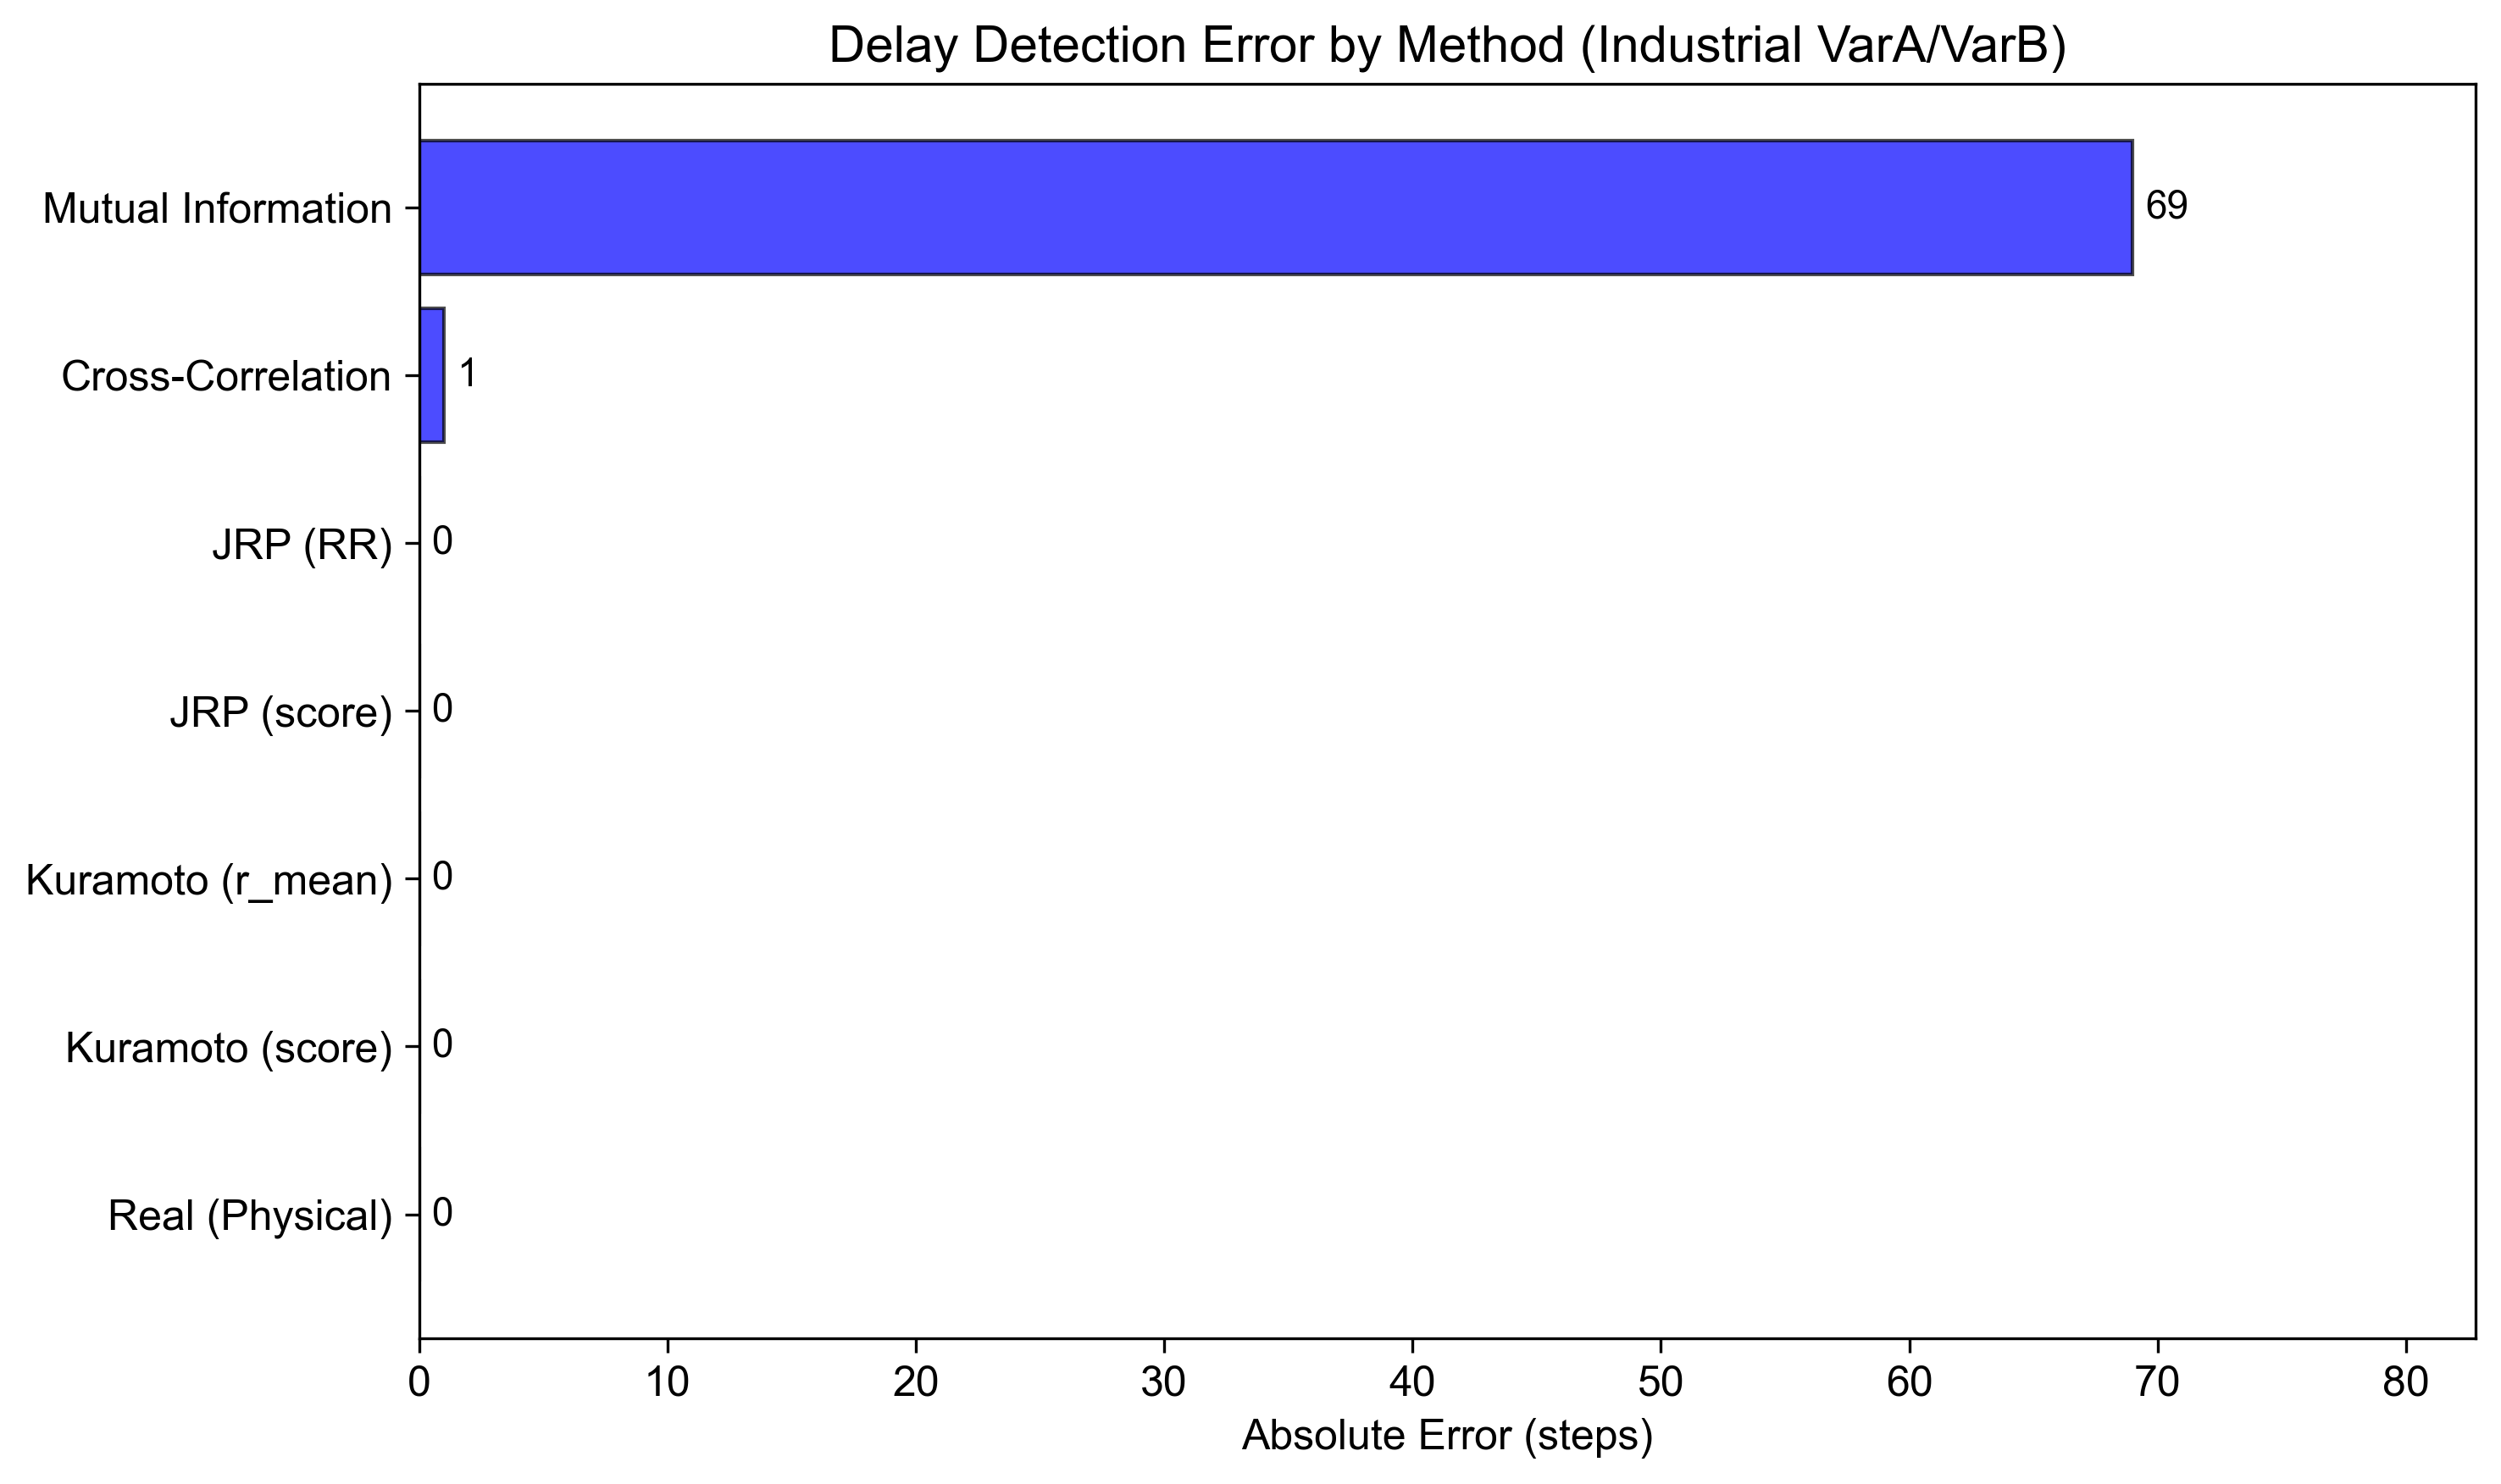

In [11]:
# --- ERROR BAR CHART ---
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')

methods = summary['Method'].tolist()
errors = summary['Error (steps)'].tolist()
colors = ['red' if m == 'Real (Physical)' else 'blue' for m in methods]
colors[0] = 'black'  # Real lag

bars = ax.barh(methods, errors, color=colors, alpha=0.7, edgecolor='black')
ax.set_xlabel('Absolute Error (steps)')
ax.set_title('Delay Detection Error by Method (Industrial VarA/VarB)')
ax.set_xlim(0, max(errors) * 1.2)

# Add value labels
for bar, err in zip(bars, errors):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{err}', va='center', ha='left', fontsize=11)

plt.tight_layout()
plt.show()